<a href="https://colab.research.google.com/github/sevdeaslanturkiyeli/AI_Development_Bootcamp/blob/main/04_dataset_initial_processing_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Initial Processing and Visualization

## Create a Dataset

In [1]:
import pandas as pd
import numpy as np


np.random.seed(42)
data = pd.DataFrame(
    {
        "customer_id ": range(1,21),
        "gender": np.random.choice(["Male","Female"],20),
        "age": np.random.randint(18,60,20),
        "income": np.random.uniform(3000,15000,20).round(2),
        "city": np.random.choice(["Istanbul","Ankara","Izmir","Konya"],20),
        "shopping_count":np.random.randint(1,20,20),
        "satisfaction":np.random.uniform(1,5,20).round(1)
    }
)

In [2]:
data

,customer_id,gender,age,income,city,shopping_count,satisfaction
0,1,Male,39,8405.99,Konya,15,2.4
1,2,Female,19,3159.18,Ankara,13,1.5
2,3,Male,41,14306.42,Ankara,9,4.5
3,4,Male,47,9759.46,Ankara,15,3.5
4,5,Male,55,7625.00,Konya,13,2.3
5,6,Female,19,3191.60,Ankara,1,1.3
6,7,Male,38,5770.73,Izmir,7,2.2
7,8,Male,50,5892.31,Konya,9,2.3
8,9,Male,29,11199.16,Izmir,1,3.9
9,10,Female,39,10319.96,Konya,12,3.6


##Dataset Review

## Overview of the dataset


In [3]:
data.head()

,customer_id,gender,age,income,city,shopping_count,satisfaction
0,1,Male,39,8405.99,Konya,15,2.4
1,2,Female,19,3159.18,Ankara,13,1.5
2,3,Male,41,14306.42,Ankara,9,4.5
3,4,Male,47,9759.46,Ankara,15,3.5
4,5,Male,55,7625.00,Konya,13,2.3


In [4]:
data.info() #data type, missing value and column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     20 non-null     int64  
 1   gender          20 non-null     object 
 2   age             20 non-null     int64  
 3   income          20 non-null     float64
 4   city            20 non-null     object 
 5   shopping_count  20 non-null     int64  
 6   satisfaction    20 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB


In [5]:
#basic statistical information
data.describe()

,customer_id,age,income,shopping_count,satisfaction
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,38.350000,8127.259000,9.000000,3.020000
std,5.91608,11.930831,3475.508974,5.467608,0.985473
min,1.00000,19.000000,3159.180000,1.000000,1.300000
25%,5.75000,31.250000,5418.182500,4.500000,2.300000
50%,10.50000,39.000000,7897.300000,9.000000,3.050000
75%,15.25000,45.500000,10539.760000,13.000000,3.900000
max,20.00000,59.000000,14306.420000,19.000000,4.500000


In [6]:
#overall size of the dataset
data.shape

(20, 7)

## Data Types and Variable Types

In [7]:
#data types
data.dtypes

,0
customer_id,int64
gender,object
age,int64
income,float64
city,object
shopping_count,int64
satisfaction,float64


In [8]:
#find numerical data

data.select_dtypes(include=["int64","float64"]).columns.tolist()

['customer_id ', 'age', 'income', 'shopping_count', 'satisfaction']

In [9]:
#find categorical data

data.select_dtypes(include=["object"]).columns.tolist()

['gender', 'city']

### Missing value and duplicate row check

In [10]:
#Missing value analysis

data.isnull().sum()

,0
customer_id,0
gender,0
age,0
income,0
city,0
shopping_count,0
satisfaction,0


In [11]:
#duplicate row check
data.duplicated().sum()

np.int64(0)

###categorical and numerical value distribution

In [12]:
for col in ["gender","city"]:
  print(data[col].unique())

['Male' 'Female']
['Konya' 'Ankara' 'Izmir' 'Istanbul']


In [13]:
for col in ["gender","city"]:
  print(data[col].value_counts())

gender
Male      13
Female     7
Name: count, dtype: int64
city
Konya       7
Ankara      7
Izmir       3
Istanbul    3
Name: count, dtype: int64


In [14]:
for col in ["age","income","shopping_count","satisfaction"]:
  print(f"{col}:{data[col].min()} - {data[col].max()}")

age:19 - 59
income:3159.18 - 14306.42
shopping_count:1 - 19
satisfaction:1.3 - 4.5


### correlation analysis


In [15]:
data.corr(numeric_only=True)

,customer_id,age,income,shopping_count,satisfaction
customer_id,1.000000,-0.027962,0.056956,-0.331929,0.262700
age,-0.027962,1.000000,0.321997,0.508299,-0.026590
income,0.056956,0.321997,1.000000,-0.001485,0.588952
shopping_count,-0.331929,0.508299,-0.001485,1.000000,-0.181684
satisfaction,0.262700,-0.026590,0.588952,-0.181684,1.000000


### simple visual inspection

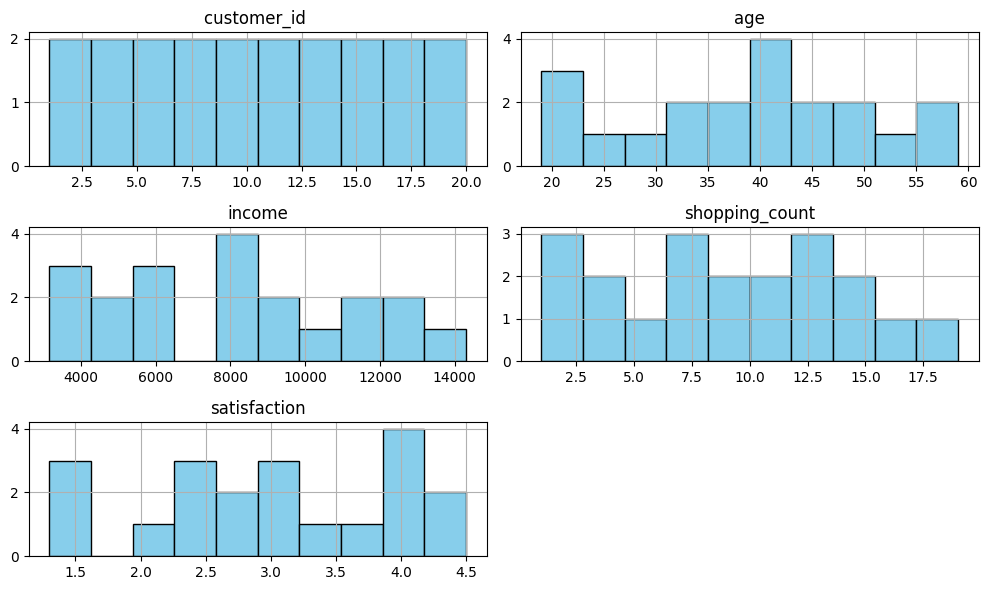

In [16]:
import matplotlib.pyplot as plt

data.hist(figsize = (10,6), bins = 10, color = "skyblue", edgecolor = "black")
plt.tight_layout()
plt.show()

## Basic Statistical Properties

## mean, median, and mode


In [17]:
#mean
data[["age","income","shopping_count","satisfaction"]].mean()

,0
age,38.350
income,8127.259
shopping_count,9.000
satisfaction,3.020


In [18]:
#median
data[["age","income","shopping_count","satisfaction"]].median()

,0
age,39.00
income,7897.30
shopping_count,9.00
satisfaction,3.05


In [19]:
#mode
data[["age"]].mode()


,age
0,19
1,38
2,39


In [20]:
data[["shopping_count"]].mode()

,shopping_count
0,1


## dispersion measures - variance, std, min, max

In [21]:
#variance

data[["age","income","shopping_count","satisfaction"]].var()

,0
age,1.423447e+02
income,1.207916e+07
shopping_count,2.989474e+01
satisfaction,9.711579e-01


In [22]:
#std
data[["age","income","shopping_count","satisfaction"]].std()

,0
age,11.930831
income,3475.508974
shopping_count,5.467608
satisfaction,0.985473


In [23]:
#min, max, quarter
data[["age","income","shopping_count","satisfaction"]].quantile([0,0.25,0.5,0.75,1])

,age,income,shopping_count,satisfaction
0.00,19.00,3159.1800,1.0,1.30
0.25,31.25,5418.1825,4.5,2.30
0.50,39.00,7897.3000,9.0,3.05
0.75,45.50,10539.7600,13.0,3.90
1.00,59.00,14306.4200,19.0,4.50


## Correlation Analysis
 1 -> positive relation
-1 -> negative relation
 0 -> no relation

In [24]:
data.corr(numeric_only = True)

,customer_id,age,income,shopping_count,satisfaction
customer_id,1.000000,-0.027962,0.056956,-0.331929,0.262700
age,-0.027962,1.000000,0.321997,0.508299,-0.026590
income,0.056956,0.321997,1.000000,-0.001485,0.588952
shopping_count,-0.331929,0.508299,-0.001485,1.000000,-0.181684
satisfaction,0.262700,-0.026590,0.588952,-0.181684,1.000000


## Visualization: Matplotlib

In [25]:
import matplotlib.pyplot as plt

In [26]:
data

,customer_id,gender,age,income,city,shopping_count,satisfaction
0,1,Male,39,8405.99,Konya,15,2.4
1,2,Female,19,3159.18,Ankara,13,1.5
2,3,Male,41,14306.42,Ankara,9,4.5
3,4,Male,47,9759.46,Ankara,15,3.5
4,5,Male,55,7625.00,Konya,13,2.3
5,6,Female,19,3191.60,Ankara,1,1.3
6,7,Male,38,5770.73,Izmir,7,2.2
7,8,Male,50,5892.31,Konya,9,2.3
8,9,Male,29,11199.16,Izmir,1,3.9
9,10,Female,39,10319.96,Konya,12,3.6


In [27]:
data.columns.tolist()

['customer_id ',
 'gender',
 'age',
 'income',
 'city',
 'shopping_count',
 'satisfaction']

### Line Plot

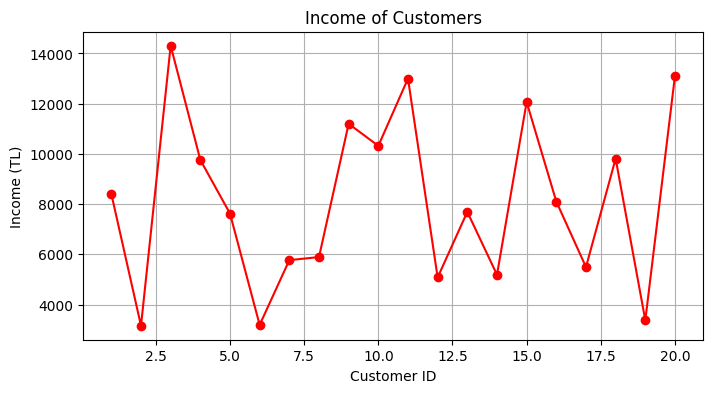

In [28]:
plt.figure(figsize = (8,4))
plt.plot(data["customer_id "], data["income"], marker = "o", color="red")
plt.title("Income of Customers")
plt.xlabel("Customer ID")
plt.ylabel("Income (TL)")
plt.grid()
plt.show()

### Scatter Plot

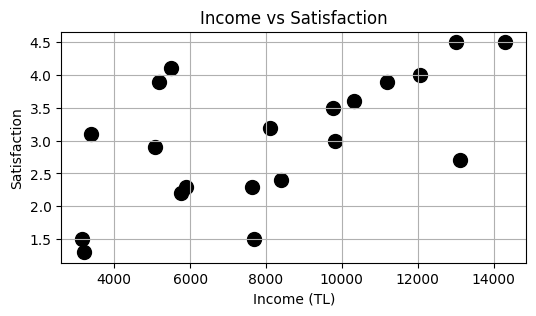

In [29]:
plt.figure(figsize = (6,3))
plt.scatter(data["income"],data["satisfaction"],s=100, color="black")
plt.xlabel("Income (TL)")
plt.ylabel("Satisfaction")
plt.title("Income vs Satisfaction")
plt.grid(True)
plt.show()

### Bar Plot

In [30]:
city_count = data["city"].value_counts()
city_count

,count
city,
Konya,7
Ankara,7
Izmir,3
Istanbul,3


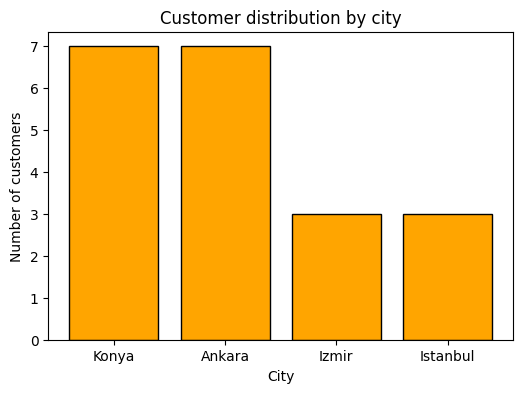

In [31]:
plt.figure(figsize = (6,4))
plt.bar(city_count.index, city_count.values, color = "orange", edgecolor = "black")
plt.title("Customer distribution by city")
plt.xlabel("City")
plt.ylabel("Number of customers")
plt.show()

### Pie Chart

In [32]:
gender_distribution = data["gender"].value_counts()
gender_distribution

,count
gender,
Male,13
Female,7


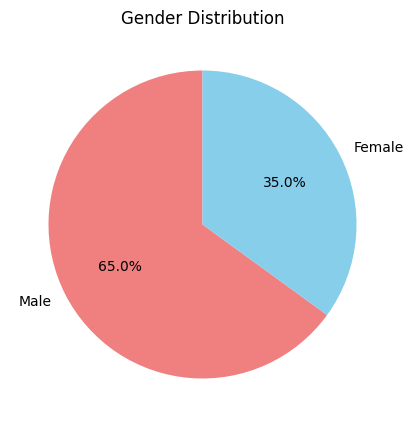

In [33]:
plt.figure(figsize = (5,5))
plt.pie(gender_distribution.values, labels = gender_distribution.index, autopct = "%1.1f%%", startangle=90, colors = ["lightcoral","skyblue"])
plt.title("Gender Distribution")
plt.show()

### Histogram

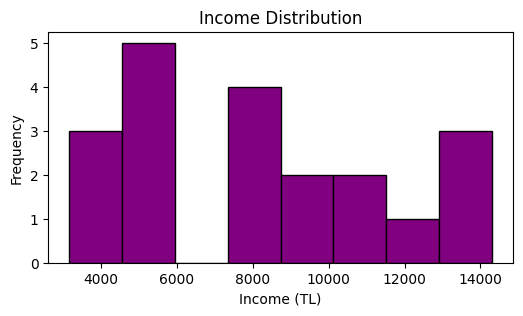

In [34]:
plt.figure(figsize=(6,3))
plt.hist(data["income"], bins = 8, color="purple", edgecolor = "black")
plt.title("Income Distribution")
plt.xlabel("Income (TL)")
plt.ylabel("Frequency")
plt.show()

### Box Plot

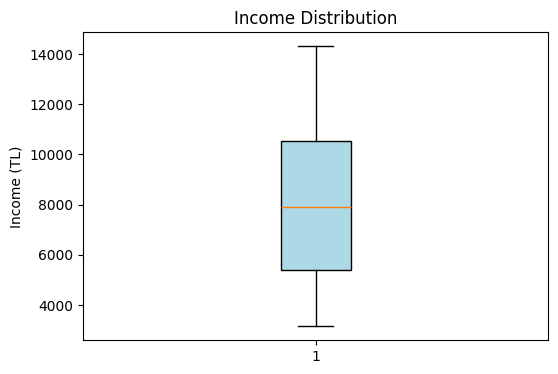

In [35]:
plt.figure(figsize =(6,4))
plt.boxplot(data["income"], patch_artist=True, boxprops=dict(facecolor = "lightblue"))
plt.title("Income Distribution")
plt.ylabel("Income (TL)")
plt.show()

### Sub Plot

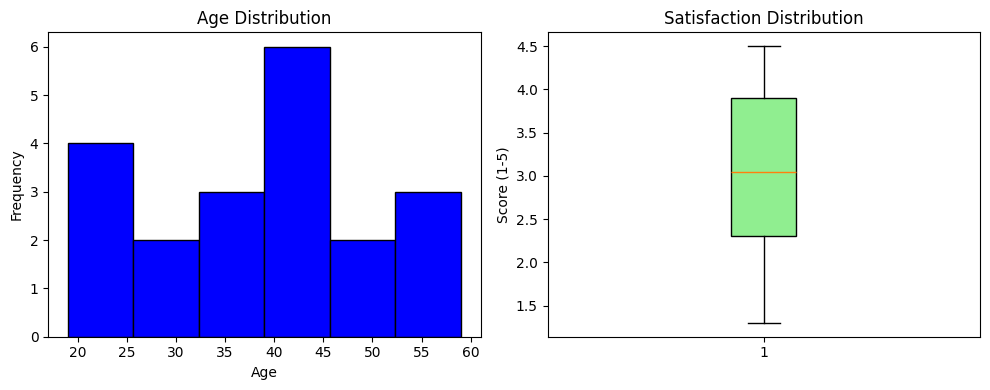

In [36]:
fig, axs = plt.subplots(1,2, figsize = (10,4))

axs[0].hist(data["age"], bins = 6 , color = "blue", edgecolor = "black")
axs[0].set_title("Age Distribution")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Frequency")

axs[1].boxplot(data["satisfaction"], patch_artist= True, boxprops=dict(facecolor = "lightgreen"))
axs[1].set_title("Satisfaction Distribution")
axs[1].set_ylabel("Score (1-5)")

plt.tight_layout()
plt.show()

## Visualization: Seaborn

### scatter plot for numerical data


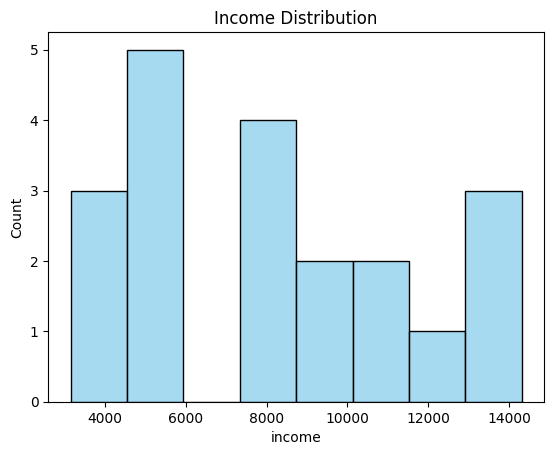

In [37]:
import seaborn as sns

#histogram

sns.histplot(data = data, x = "income", bins = 8, kde =False, color = "skyblue")
plt.title("Income Distribution")
plt.show()

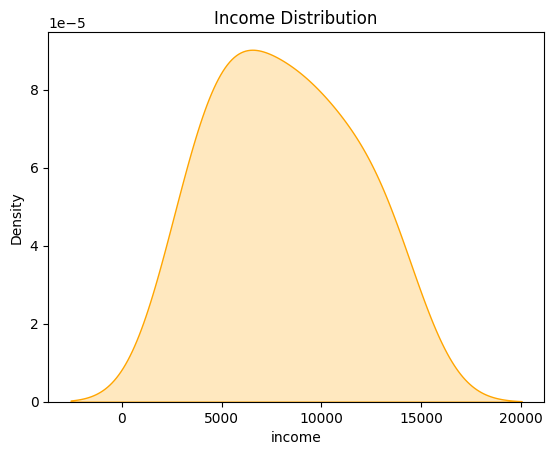

In [38]:
#kernel destiny estimation

sns.kdeplot(data =data, x="income", fill = True, color = "orange")
plt.title("Income Distribution")
plt.show()

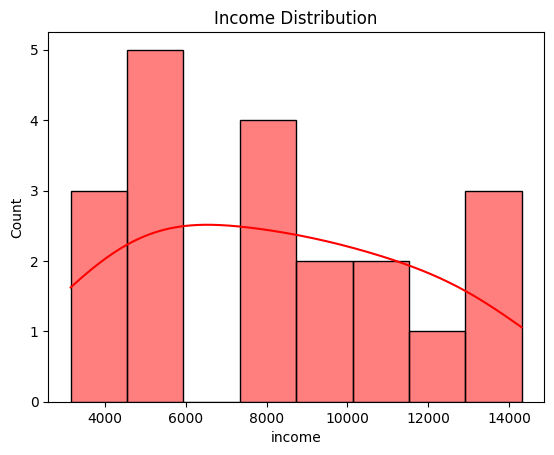

In [39]:
# histogram + kde

sns.histplot(data = data, x = "income", bins = 8, kde = True, color = "red")
plt.title("Income Distribution")
plt.show()

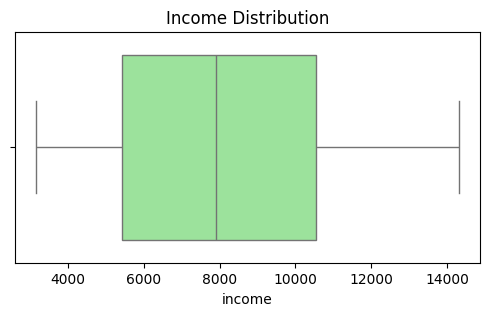

In [41]:
# boxplot

plt.figure(figsize=(6,3))
sns.boxplot(data = data, x="income", color = "lightgreen")
plt.title("Income Distribution")
plt.show()

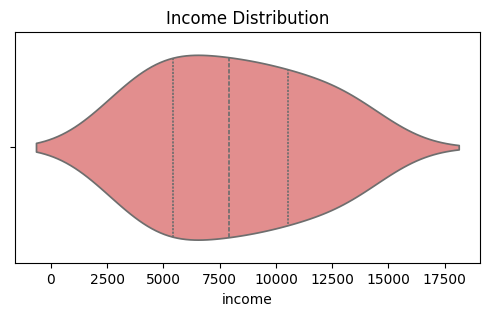

In [42]:
# violin plot (scatter + density)

plt.figure(figsize = (6,3))
sns.violinplot(data = data, x = "income", inner = "quartile", color = "lightcoral")
plt.title("Income Distribution")
plt.show()

### Categorical Variables

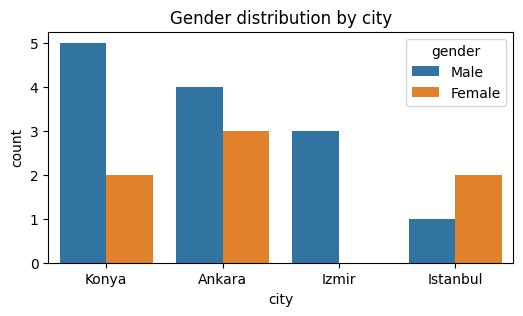

In [44]:
#countplot - Shows the frequency of categories
plt.figure(figsize = (6,3))
sns.countplot(data = data, x = "city", hue = "gender")
plt.title("Gender distribution by city")
plt.show()

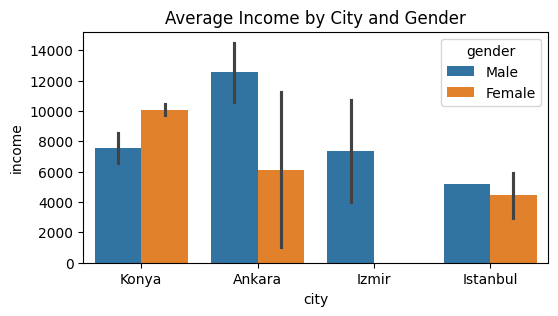

In [48]:
# barplot -average or total value by category

plt.figure(figsize = (6,3))
sns.barplot(data = data, x="city", y = "income", hue ="gender", errorbar = "sd")
plt.title("Average Income by City and Gender")
plt.show()

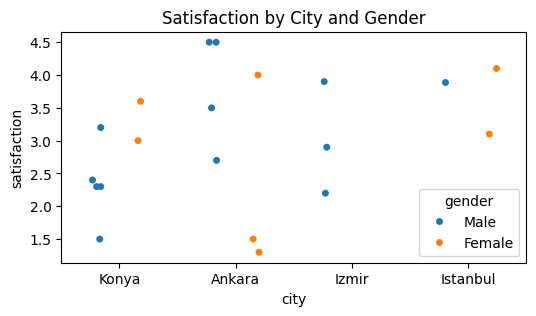

In [50]:
# strip plot

plt.figure(figsize = (6,3))
sns.stripplot(data = data, x = "city", y = "satisfaction", hue = "gender", jitter = True, dodge = True)
plt.title("Satisfaction by City and Gender")
plt.show()

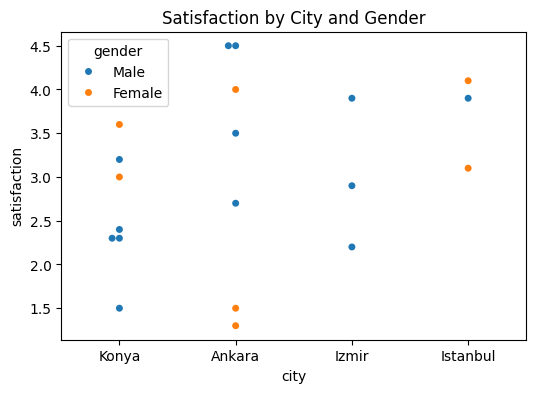

In [51]:
# swarm plot

plt.figure(figsize = (6,4))
sns.swarmplot(data=data, x="city",y="satisfaction", hue = "gender")
plt.title("Satisfaction by City and Gender")
plt.show()


### charts showing relationships


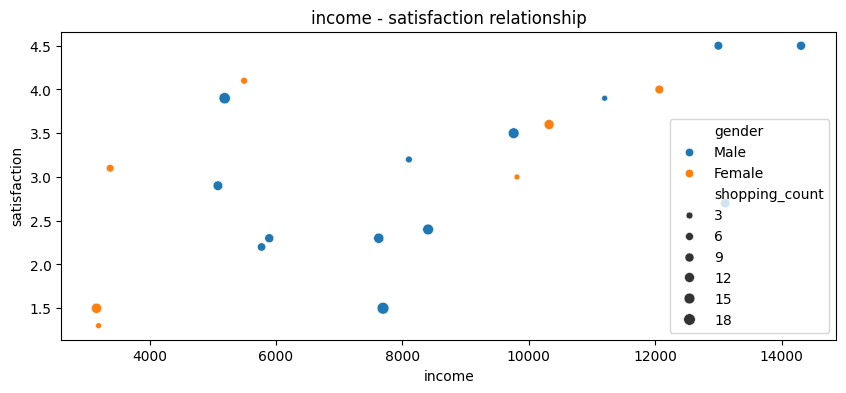

In [55]:
# scatter plot -the relationship between two numerical variables

plt.figure(figsize=(10,4))
sns.scatterplot(data = data, x="income", y="satisfaction",hue="gender",size="shopping_count")
plt.title("income - satisfaction relationship")
plt.show()



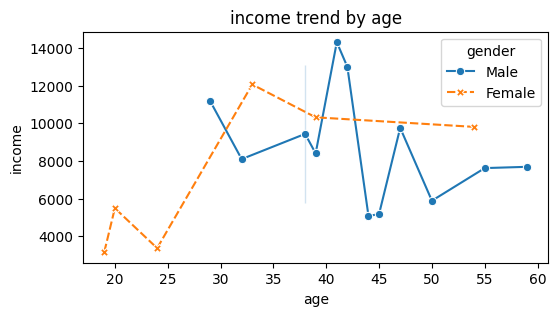

In [60]:
# line plot - tendency of values ​​to change

plt.figure(figsize= (6,3))
sns.lineplot(data = data, x ="age",y ="income", hue = "gender", style = "gender",markers = True)
plt.title("income trend by age")
plt.show()

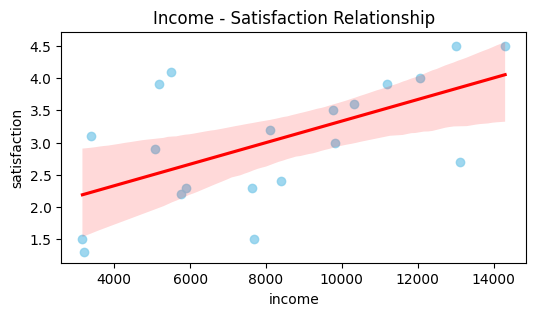

In [63]:
#regplot

plt.figure(figsize = (6,3))
sns.regplot(data = data, x ="income", y = "satisfaction", scatter_kws = {"color":"skyblue"}, line_kws = {"color":"red"})
plt.title("Income - Satisfaction Relationship")
plt.show()

<Figure size 640x480 with 0 Axes>

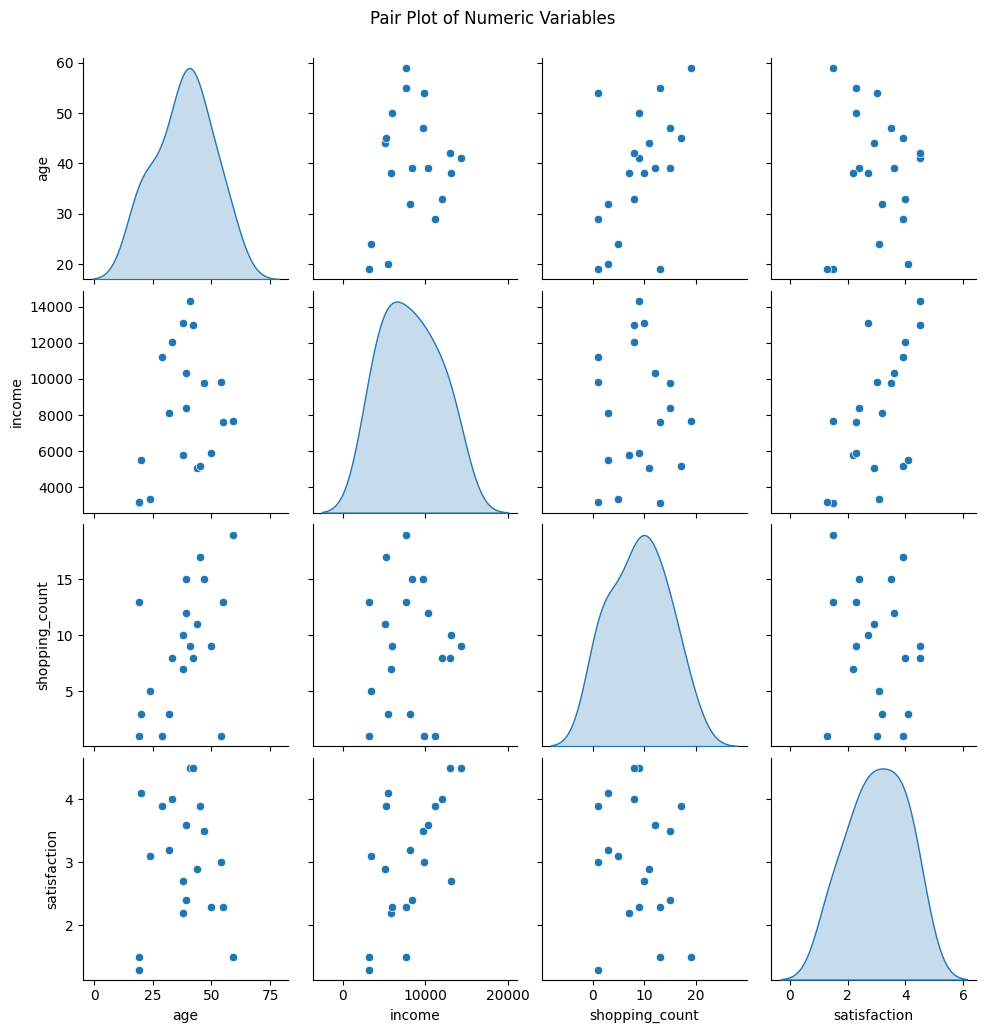

In [66]:
# pair plot - multiple numeric variable relationship

plt.figure()
sns.pairplot(data[["age","income","shopping_count","satisfaction"]], diag_kind = "kde")
plt.suptitle("Pair Plot of Numeric Variables", y=1.03)
plt.show()

##Correlation Analyzes

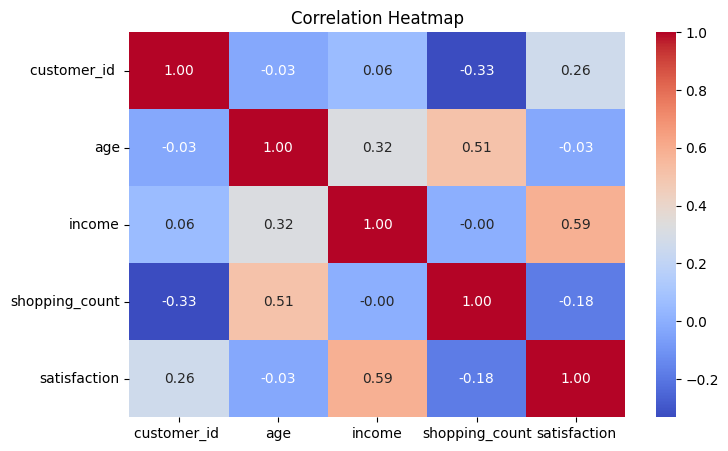

In [69]:
# heatmap

plt.figure(figsize = (8,5))
sns.heatmap(data.corr(numeric_only = True), annot = True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<Figure size 640x480 with 0 Axes>

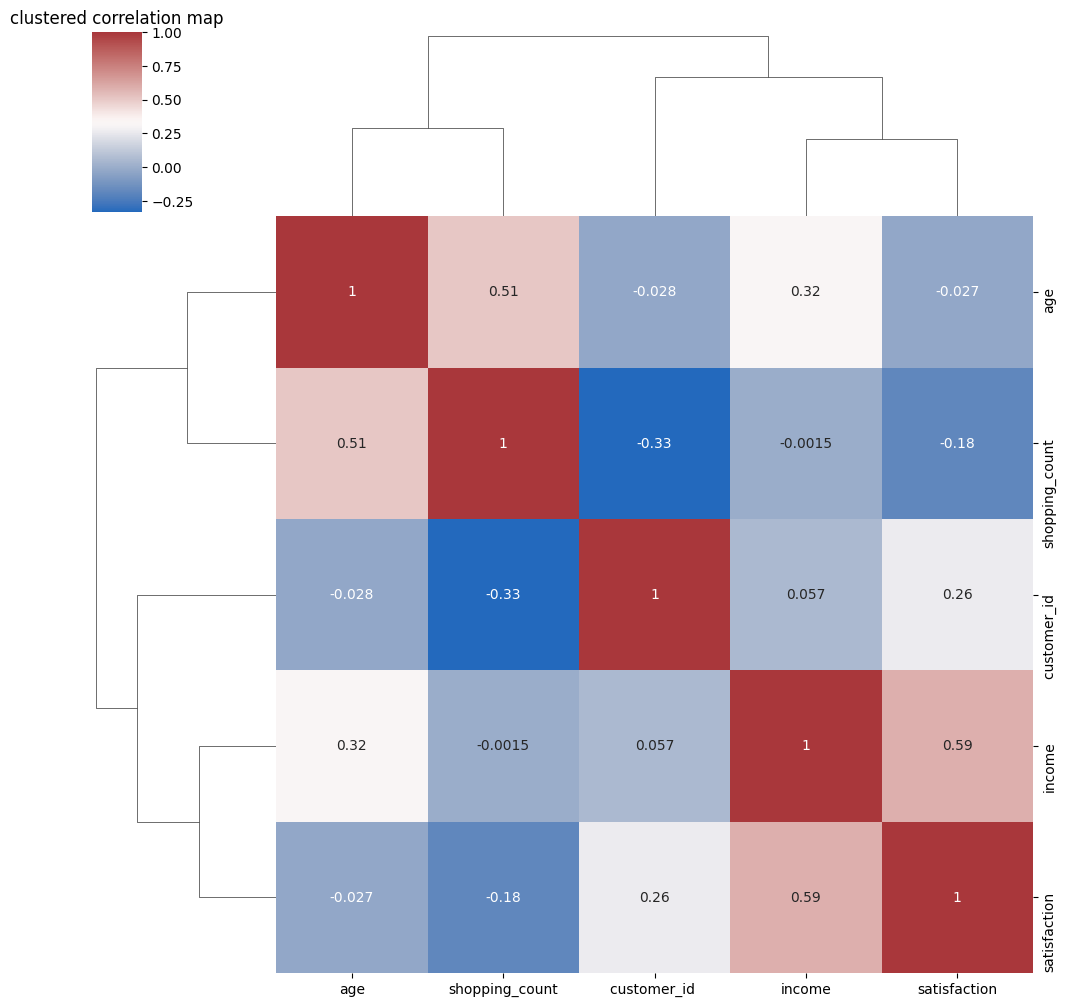

In [71]:
# cluster map
plt.figure()
sns.clustermap(data.corr(numeric_only= True), annot = True, cmap = "vlag")
plt.title("clustered correlation map")
plt.show()

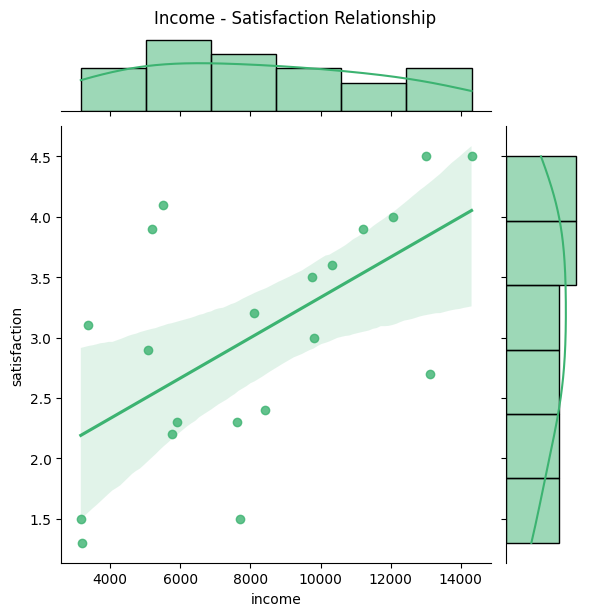

In [72]:
# jointplot

sns.jointplot(data = data, x ="income", y="satisfaction", kind="reg", color="mediumseagreen")
plt.suptitle("Income - Satisfaction Relationship", y=1.02)
plt.show()

## multiple visualization


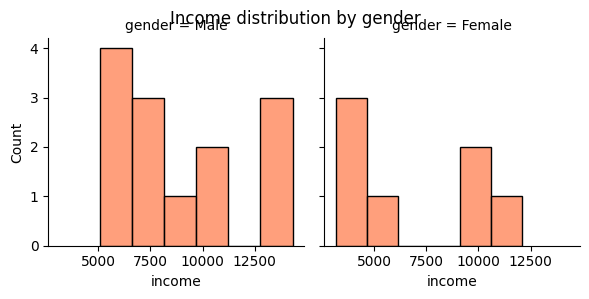

In [74]:
# facetgrid

g = sns.FacetGrid(data, col ="gender")
g.map(sns.histplot, "income", bins=6,color="coral")
g.fig.suptitle("Income distribution by gender")
plt.show()

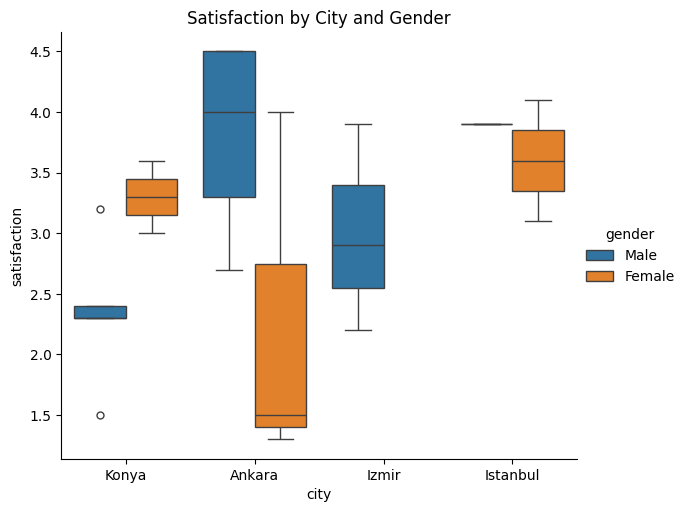

In [78]:
# catplot - combination of categorical graphs

sns.catplot(data = data, x="city", y="satisfaction", hue ="gender", kind="box", height = 5, aspect=1.2)
plt.title("Satisfaction by City and Gender")
plt.show()

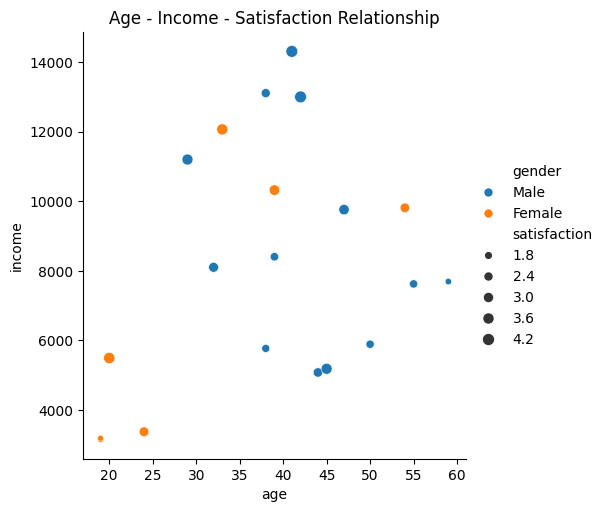

In [80]:
# relplot - (scatter/line)

sns.relplot(data=data, x="age", y="income", hue = "gender", size = "satisfaction", kind="scatter")
plt.title("Age - Income - Satisfaction Relationship")
plt.show()